###Nguyễn Thiên An


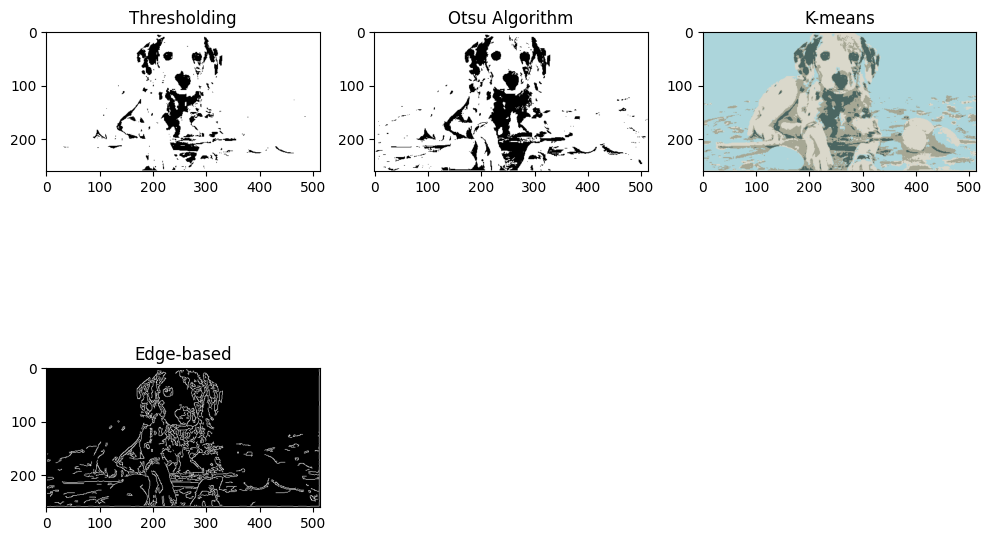

In [3]:
# Kiểm tra và cài đặt opencv-python
!pip install opencv-python

import cv2 as cv
import numpy as np
# LƯU Ý: Thay "TenSV" bằng tên của bạn (không dấu)
import matplotlib.pyplot as TenSV

# Đọc ảnh theo đúng định dạng yêu cầu
img = cv.imread('hinh1.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 1. Thresholding
ret, thresh1 = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)

# 2. Otsu algorithm (phân đoạn ảnh vân tay)
ret2, thresh_otsu = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# 3. Clustering techniques trong phân đoạn ảnh, K-mean clustering
Z = img.reshape((-1,3))
Z = np.float32(Z)
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 4
ret_k, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res_kmeans = center[label.flatten()].reshape((img.shape))

# 4. Region growing (Sử dụng FloodFill làm phương pháp lấp đầy vùng tương đương)
img_rg = img.copy()
mask = np.zeros((img.shape[0]+2, img.shape[1]+2), np.uint8)
cv.floodFill(img_rg, mask, (0,0), (255,0,0))

# 5. Split and merge (Sử dụng thuật toán Watershed tương tự để phân chia vùng)
ret_ws, markers = cv.connectedComponents(thresh_otsu)
markers = markers + 1
markers[thresh_otsu == 255] = 0
img_watershed = img.copy()
cv.watershed(img_watershed, markers)

# 6. Edge-based segmentation
edges = cv.Canny(img_gray, 100, 200)

# Hiển thị ảnh (Sử dụng TenSV thay vì plt theo đúng yêu cầu)
TenSV.figure(figsize=(12, 8))
TenSV.subplot(231), TenSV.imshow(thresh1, cmap='gray'), TenSV.title('Thresholding')
TenSV.subplot(232), TenSV.imshow(thresh_otsu, cmap='gray'), TenSV.title('Otsu Algorithm')
TenSV.subplot(233), TenSV.imshow(cv.cvtColor(res_kmeans, cv.COLOR_BGR2RGB)), TenSV.title('K-means')
TenSV.subplot(234), TenSV.imshow(edges, cmap='gray'), TenSV.title('Edge-based')
TenSV.show()